### Build A Basic Chatbot With Langgraph(Graph Api)

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [9]:
class State(TypedDict):
    # Messages have type "list". The 'add_message' function
    # in the annotation defines how this state key should be updated
    #(in this case, it appends messages to list , rather than overwritting them)
    messages : Annotated[list,add_messages]
graph_builder = StateGraph(State)    

In [10]:
graph_builder

In [11]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [12]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-120b")

In [13]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x112ded7f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x112dee510>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [14]:
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x112f08a50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x112f09450>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [15]:
# Node funcationality
def chatbot(state:State):
    # print(state)
    return {"messages":[llm.invoke(state["messages"])]}

In [16]:
graph_builder = StateGraph(State)

# Adding node
graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

# graph compile
graph = graph_builder.compile()

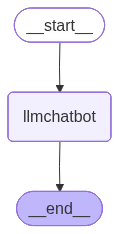

In [17]:
## Visualize this graph
from IPython.display import Image,display


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [18]:
response = graph.invoke({"messages":"Hi"})

response['messages'][-1].content

'Hello! How can I assist you today?'

In [19]:
for event in graph.stream({"messages":"Hi How are you?"}):
    # print(event)
    for value in event.values():
        # print(value['messages'][0])
        print(value['messages'][-1].content)

Hello! I'm doing great, thank you for asking. How can I assist you today?


In [20]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke('what is langgraph')


{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph',
   'content': '`LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? The classes from LangChain might be used in LangGraph, but do not HAVE to be used. The packages are different and can be used in isolation, but, in the end, all resources you will find online use both packages hand in hand. `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your application involve

In [21]:
# Custom Function
def multipy(a:int,b:int)-> int:
    """Multilpy a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [23]:
tools = [tool,multipy]
llm_with_tools=llm.bind_tools(tools)

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm) 
builder.add_node("tools",ToolNode(tools))

# Add Edegs
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_consition routes to tools
    # if the latest message (result) from assistent is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

graph = builder.compile()



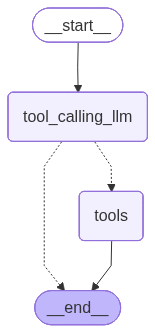

In [28]:
# Visualize the graph 
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass    

In [37]:
response = graph.invoke({"messages":"What is the recent ai news?"})


In [39]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_040aad44-d1f4-454d-94c7-afaa701d334f)
 Call ID: fc_040aad44-d1f4-454d-94c7-afaa701d334f
  Args:
    query: latest AI news May 2026
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news May 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-anthropic-model-too-dangerous-go-public", "title": "Fox News AI Newsletter: The AI model that's too dangerous to go public - Fox News", "score": 0.6241337, "published_date": "Fri, 01 May 2026 14:29:35 GMT", "content": "This material may not be published, broadcast, rewritten, or redistributed. ©2026 FOX News Network, L

In [42]:
response = graph.invoke({"messages":"What is 2 multiply by 3?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3?
================================== Ai Message ==================================

2 × 3 = 6.


In [46]:
response = graph.invoke({"messages":"give we the rescent ai new and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

give we the rescent ai new and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_33bd8523-b923-40bd-a06a-3b4edf67b44e)
 Call ID: fc_33bd8523-b923-40bd-a06a-3b4edf67b44e
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.mitsloanme.com/article/ai-compute-costs-exceed-workforce-costs-nvidia-executive-says/", "title": "AI Compute Costs Exceed Workforce Costs, Nvidia Executive Says - MIT Sloan Management Review Middle East", "score": 0.7293082, "published_date": "Wed, 29 Apr 2026 13:27:28 GMT", "content": "Popular Searches\n\nleadership\n\nnexttech\n\nAI\n\nnext

### ReAct Agent Architecture 

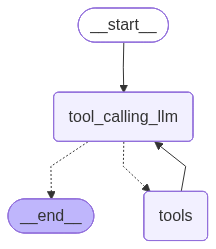

In [50]:
## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm) 
builder.add_node("tools",ToolNode(tools))

# Add Edegs
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_consition routes to tools
    # if the latest message (result) from assistent is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

# Visualize the graph 


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass 


In [51]:
response = graph.invoke({"messages":"give we the rescent ai new and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

give we the rescent ai new and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_7bb20f1b-8bd4-4ab1-abfa-3029f87ebda0)
 Call ID: fc_7bb20f1b-8bd4-4ab1-abfa-3029f87ebda0
  Args:
    query: latest AI news 2024 May
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2024 May", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://sandbergphoenix.com/the-uncertain-future-of-state-ai/", "title": "The Uncertain Future of State AI Regulation: Lessons from xAI v. Colorado - Sandberg Phoenix", "content": "In the absence of an enacted comprehensive federal AI statute, states have moved to address perceived gaps. Colorado was the first state to enact a comprehensive AI law. Se

### Adding Memory In Agentic Graph

In [52]:
response = graph.invoke({"messages":"Hello, my name is Akash"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, my name is Akash
================================== Ai Message ==================================

Hello Akash! 👋 Nice to meet you. How can I assist you today?


In [53]:
response = graph.invoke({"messages":"Hello, What is my name ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, What is my name ?
================================== Ai Message ==================================

I’m not able to see your name from our conversation so far. Could you let me know how you’d like to be addressed?


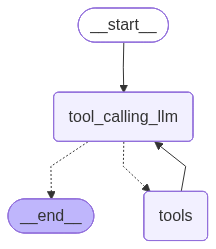

In [54]:
from langgraph.checkpoint.memory import MemorySaver


memory = MemorySaver()
## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm) 
builder.add_node("tools",ToolNode(tools))

# Add Edegs
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_consition routes to tools
    # if the latest message (result) from assistent is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph = builder.compile(checkpointer=memory)

# Visualize the graph 


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass 


In [ ]:
config = {
    "configurable":{
        "thread_id":"1"
    }
}
response = graph.invoke({"messages":"My name is akash"},config=config)

{'messages': [HumanMessage(content='My name is akash', additional_kwargs={}, response_metadata={}, id='7ccfece1-c44d-4db4-b6a2-f2a49388ac74'),
  AIMessage(content='Nice to meet you, Akash! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "My name is akash". Likely they are introducing themselves. The assistant should respond politely, acknowledging the name, perhaps asking how to help. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 350, 'total_tokens': 412, 'completion_time': 0.137717185, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.01298999, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.050764339, 'total_time': 0.150707175}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dee4c-74dc-75d1-a74c-f2f454757278-0', tool_ca

In [59]:
response['messages'][-1].content

'Nice to meet you, Akash! How can I assist you today?'

In [60]:
response = graph.invoke({"messages":"Hey, What is my name?"},config=config)
response['messages'][-1].content

'Your name is Akash.'

In [61]:
response = graph.invoke({"messages":"Hye , do you remember me?"},config=config)
response['messages'][-1].content

'Hey Akash!\u202fI’ve got you on record from our earlier messages—your name is Akash. How can I help you today?'

### Streaming

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [63]:
def superbot(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}



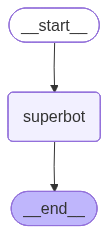

In [64]:
## Graph
builder = StateGraph(State)
builder.add_node("superbot",superbot) 
# builder.add_node("tools",ToolNode(tools))

# Add Edegs
builder.add_edge(START,"superbot")
# builder.add_conditional_edges(
#     "tool_calling_llm",
#     # if the latest message (result) from assistant is a tool call -> tools_consition routes to tools
#     # if the latest message (result) from assistent is a not a tool call -> tools_condition routes to END
#     tools_condition
# )
builder.add_edge("superbot",END)

graph = builder.compile(checkpointer=memory)

# Visualize the graph 


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass 


In [65]:
for chunks in graph.stream({"messages":"Hi, My name is akash and i like cricket"},config,stream_mode="updates"):
    print(chunks)
    # for value in event.values():
    #     # print(value['messages'][0])
    #     print(value['messages'][-1].content)

{'superbot': {'messages': [AIMessage(content="Got it, Akash! A cricket fan—nice! 🎉 Whether you want to chat about the latest matches, discuss players, or need any info related to the sport (or anything else), just let me know. I'm here to help!", additional_kwargs={'reasoning_content': 'User says name akash and likes cricket. Probably wants to continue conversation. No question. Should respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 456, 'total_tokens': 538, 'completion_time': 0.178863496, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.011357172, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.052824258, 'total_time': 0.190220668}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4a19b1544c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dee55-e45f-7fe2-87e3-25d7373888c4-0', tool_calls=[], invalid_tool_calls=[], us

In [68]:
async for chunks in graph.astream_events({"messages":"Hi, My name is akash and i like cricket"},config,stream_mode="values"):
    print(chunks)
    # for value in event.values():
    #     # print(value['messages'][0])
    #     print(value['messages'][-1].content)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is akash and i like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019dee57-a85f-7fd0-910c-9025288f6633', 'metadata': {'thread_id': '1', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '019dee57-a85f-7fd0-910c-9025288f6633', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '1', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='My name is akash', additional_kwargs={}, response_metadata={}, id='7ccfece1-c44d-4db4-b6a2-f2a49388ac74'), AIMessage(content='Nice to meet you, Akash! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "My name is akash". Likely they are introducing themselves. The assistant should respond politely, acknowledging the name, perhaps asking how to help. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 350, 'total_tokens':

### Human In The Loop

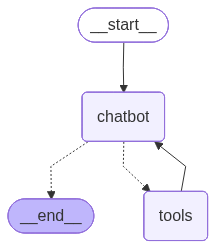

In [75]:
from langchain.tools import tool
from langgraph.types import interrupt,Command

@tool
def human_assistance(query:str)->str:
    """ Request assistance from a human """
    human_response = interrupt({"query":query})
    return human_response['data']

tool = TavilySearch(max_results=2)
tool.invoke('what is langgraph')

tools = [tool,human_assistance]
llm_with_tools=llm.bind_tools(tools)

def chatbot(state=State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

## Graph


graph_builder = StateGraph(State)

# Adding node
graph_builder.add_node("chatbot",chatbot)
graph_builder.add_node("tools",ToolNode(tools=tools))
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("tools","chatbot")
# graph compile
graph = graph_builder.compile()


try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass 

In [72]:
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

In [74]:
user_input = "I need some expert guidence for building an AI agent. could you request assistance for me?"
config = {
    "configurable":{"thread_id":"1"}
}

events = graph.stream(
    {"messages":user_input},
    config=config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event['messages'][-1].pretty_print()



================================ Human Message =================================

I need some expert guidence for building an AI agent. could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_0a7f589f-4702-49b9-9d7c-31de7bc17095)
 Call ID: fc_0a7f589f-4702-49b9-9d7c-31de7bc17095
  Args:
    query: User requests expert guidance for building an AI agent. Please provide detailed assistance on architecture, tools, best practices, and resources.


In [76]:
human_reponse = (
    "we, the experts are here to help! we'd recommend you check out langgraph to build you agent."
    "it's much more reliable and extensible than simple autonomouse agents"
)

humand_command = Command(resume={"data":human_reponse})

events = graph.stream(
    {"messages":user_input},
    config=config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event['messages'][-1].pretty_print()

================================ Human Message =================================

I need some expert guidence for building an AI agent. could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_c99bb852-5e3b-4a28-8549-445fa5e3e936)
 Call ID: fc_c99bb852-5e3b-4a28-8549-445fa5e3e936
  Args:
    query: User requests expert guidance for building an AI agent. Please provide detailed assistance on architecture, tools, best practices, and any relevant resources.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_c99bb852-5e3b-4a28-8549-445fa5e3e936)
 Call ID: fc_c99bb852-5e3b-4a28-8549-445fa5e3e936
  Args:
    query: User requests expert guidance for building an AI agent. Please provide detailed assistance on architecture, tools, best practices, and any relevant resources.
